# Screening delle process execution reali

Questo notebook estende la verifica effettuata durante la derivazione automatica delle causal relations.

La pipeline non viene più applicata soltanto all'ordine semplice `o-990424`, ma a tutte le **22 process execution complete e non contaminate** individuate nel dataset Order Management.

Gli obiettivi sono:

- verificare il comportamento con più item e più pacchi;
- analizzare le principali eccezioni del processo;
- gestire le attività ripetute sullo stesso oggetto;
- evitare di imporre un ordine tra eventi uguali riferiti a oggetti differenti;
- controllare che tutti gli Instance Graph siano DAG transitivamente ridotti.

## 1. Limite metodologico

Le causal relations utilizzate in questo notebook vengono inferite dall'Object-Centric Directly-Follows Graph.

La procedura utilizza:

- la dependency measure per attività differenti;
- il supporto relativo per eliminare archi scarsamente rappresentativi;
- il self-loop score per attività seguite dalla stessa attività.

Questa analisi verifica la struttura dei grafi ottenuti. Non costituisce ancora un conformance checking object-centric formale rispetto alla OCPN.

In [1]:
import sys

from IPython.display import Image, display
import networkx as nx
import pandas as pd
import pm4py

from ocpm_partial_order.config import (
    GRAPHS_DIR,
    MAIN_DATASET_DB,
    PROJECT_ROOT,
)
from ocpm_partial_order.discovery import (
    DEFAULT_DEPENDENCY_THRESHOLD,
    DEFAULT_RELATIVE_SUPPORT_THRESHOLD,
    DEFAULT_SELF_LOOP_THRESHOLD,
    derive_causal_relations,
    score_causal_relations,
)
from ocpm_partial_order.extraction import (
    extract_order_centred_execution,
)
from ocpm_partial_order.graphs.concurrency import (
    find_incomparable_event_pairs,
)
from ocpm_partial_order.graphs.instance_graph import (
    build_instance_graph,
)
from ocpm_partial_order.io.ocel_loader import (
    load_ocel2_sqlite,
)
from ocpm_partial_order.visualization.graph_visualizer import (
    save_instance_graph,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.screen_order_executions import (
    EXCEPTION_ACTIVITIES,
    ORDER_IDS,
    failed_delivery_chain,
    find_suspicious_repetitions,
)

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 20)

print("Import completati")
print("Dataset:", MAIN_DATASET_DB)
print("Execution da analizzare:", len(ORDER_IDS))



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Import completati
Dataset: C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\data\raw\order_management.sqlite
Execution da analizzare: 22


## 2. Soglie utilizzate

Le soglie restano uguali a quelle adottate nella derivazione automatica delle causal relations, con l'aggiunta di una soglia specifica per i self-loop.

In [2]:
print(
    "Dependency threshold:",
    DEFAULT_DEPENDENCY_THRESHOLD,
)
print(
    "Relative support threshold:",
    DEFAULT_RELATIVE_SUPPORT_THRESHOLD,
)
print(
    "Self-loop threshold:",
    DEFAULT_SELF_LOOP_THRESHOLD,
)

Dependency threshold: 0.9
Relative support threshold: 0.05
Self-loop threshold: 0.9


## 3. Caricamento dell'OCEL e derivazione delle relazioni

L'OC-DFG viene scoperto una sola volta sull'intero log. Le causal relations risultanti vengono poi applicate separatamente a ciascuna process execution.

In [3]:
ocel = load_ocel2_sqlite(
    MAIN_DATASET_DB
)

ocdfg = pm4py.discover_ocdfg(ocel)

evidence = score_causal_relations(
    ocdfg=ocdfg,
    object_types={
        "orders",
        "items",
        "packages",
    },
)

causal_relations = derive_causal_relations(
    ocdfg=ocdfg,
    dependency_threshold=(
        DEFAULT_DEPENDENCY_THRESHOLD
    ),
    relative_support_threshold=(
        DEFAULT_RELATIVE_SUPPORT_THRESHOLD
    ),
    self_loop_threshold=(
        DEFAULT_SELF_LOOP_THRESHOLD
    ),
    object_types={
        "orders",
        "items",
        "packages",
    },
)

self_evidence = [
    item
    for item in evidence
    if item.relation.source_activity
    == item.relation.target_activity
    and item.relation in causal_relations
]

print(
    "Causal relations derivate:",
    len(causal_relations),
)
print(
    "Auto-relazioni derivate:",
    len(self_evidence),
)

Causal relations derivate: 26
Auto-relazioni derivate: 4


## 4. Auto-relazioni riconosciute

Un'auto-relazione indica che, per uno stesso tipo di oggetto, un'attività può essere seguita nuovamente dalla stessa attività.

Il self-loop score è:

```text
frequenza(A → A) / (frequenza(A → A) + 1)
```

Una relazione viene conservata soltanto se supera sia la self-loop threshold sia il supporto relativo.

In [4]:
self_loop_table = pd.DataFrame(
[
{
"object_type": (
item.relation.object_type
),
"activity": (
item.relation.source_activity
),
"frequency": (
item.forward_frequency
),
"relative_support": (
item.relative_support
),
"self_loop_score": (
item.self_loop_score
),
}
for item in self_evidence
]
).sort_values(
[
"object_type",
"activity",
]
).reset_index(drop=True)

display(self_loop_table)

assert len(causal_relations) == 26
assert len(self_loop_table) == 4

,object_type,activity,frequency,relative_support,self_loop_score
0,items,failed delivery,96,0.450704,0.989691
1,items,payment reminder,122,0.276018,0.991870
2,orders,payment reminder,123,0.277652,0.991935
3,packages,failed delivery,97,0.453271,0.989796


## 5. Costruzione dei 22 Instance Graph

Per ogni ordine vengono controllate le seguenti proprietà:

assenza di cicli;
connessione debole;
copertura di tutti gli eventi;
assenza di nodi isolati;
riduzione transitiva;
assenza di attività ripetute incomparabili sullo stesso oggetto strutturale.

In [5]:
executions = {}
graphs = {}
screening_rows = []

for order_id in ORDER_IDS:
    execution = extract_order_centred_execution(
    ocel=ocel,
    order_id=order_id,
    )

    graph = build_instance_graph(
        execution=execution,
        causal_relations=causal_relations,
    )

    executions[order_id] = execution
    graphs[order_id] = graph

    is_dag = nx.is_directed_acyclic_graph(
        graph
    )

    weakly_connected = (
        graph.number_of_nodes() > 0
        and nx.is_weakly_connected(graph)
    )

    covered_nodes = {
        node
        for node in graph.nodes
        if (
            graph.in_degree(node)
            + graph.out_degree(node)
        ) > 0
    }

    isolated_nodes = (
        set(graph.nodes) - covered_nodes
    )

    incomparable_pairs = (
        find_incomparable_event_pairs(graph)
    )

    suspicious_repetitions = (
        find_suspicious_repetitions(
            execution,
            graph,
        )
    )

    transitively_reduced = (
        is_dag
        and set(
            nx.transitive_reduction(
                graph
            ).edges
        )
        == set(graph.edges)
    )

    activities = {
        event.activity
        for event in execution.events
    }

    exceptions = sorted(
        activities & EXCEPTION_ACTIVITIES
    )

    valid = all(
        (
            is_dag,
            weakly_connected,
            len(covered_nodes)
            == graph.number_of_nodes(),
            not isolated_nodes,
            transitively_reduced,
            not suspicious_repetitions,
        )
    )

    screening_rows.append(
        {
            "order_id": order_id,
            "events": (
                graph.number_of_nodes()
            ),
            "edges": (
                graph.number_of_edges()
            ),
            "dag": is_dag,
            "weakly_connected": (
                weakly_connected
            ),
            "coverage": (
                f"{len(covered_nodes)}/"
                f"{graph.number_of_nodes()}"
            ),
            "transitively_reduced": (
                transitively_reduced
            ),
            "incomparable_pairs": (
                len(incomparable_pairs)
            ),
            "sources": sum(
                graph.in_degree(node) == 0
                for node in graph.nodes
            ),
            "sinks": sum(
                graph.out_degree(node) == 0
                for node in graph.nodes
            ),
            "exceptions": (
                ", ".join(exceptions)
                if exceptions
                else "nessuna"
            ),
            "suspicious_repetitions": (
                len(suspicious_repetitions)
            ),
            "valid": valid,
        }
    )

screening_table = pd.DataFrame(
screening_rows
)

display(screening_table)

,order_id,events,edges,dag,weakly_connected,coverage,transitively_reduced,incomparable_pairs,sources,sinks,exceptions,suspicious_repetitions,valid
0,o-990424,7,6,True,True,7/7,True,8,1,2,nessuna,0,True
1,o-991749,7,6,True,True,7/7,True,8,1,2,nessuna,0,True
2,o-990878,8,8,True,True,8/8,True,11,1,2,nessuna,0,True
3,o-991284,8,8,True,True,8/8,True,11,1,2,nessuna,0,True
4,o-990387,9,10,True,True,9/9,True,15,1,2,nessuna,0,True
5,o-990916,9,10,True,True,9/9,True,15,1,2,nessuna,0,True
6,o-991630,9,10,True,True,9/9,True,15,1,2,nessuna,0,True
7,o-991982,9,10,True,True,9/9,True,15,1,2,nessuna,0,True
8,o-990077,10,11,True,True,10/10,True,17,1,2,failed delivery,0,True
9,o-991686,10,12,True,True,10/10,True,20,1,2,nessuna,0,True


## 6. Riepilogo dello screening

Un'esecuzione supera lo screening soltanto se soddisfa contemporaneamente tutti i controlli strutturali.

In [6]:
summary = pd.DataFrame(
[
{
"execution_previste": (
len(ORDER_IDS)
),
"execution_superate": int(
screening_table[
"valid"
].sum()
),
"execution_fallite": int(
(
~screening_table[
"valid"
]
).sum()
),
"ripetizioni_sospette": int(
screening_table[
"suspicious_repetitions"
].sum()
),
}
]
)

display(summary)

assert len(screening_table) == 22
assert screening_table["valid"].all()
assert (
screening_table[
"suspicious_repetitions"
].sum()
== 0
)

print("SCREENING COMPLETO SUPERATO")

,execution_previste,execution_superate,execution_fallite,ripetizioni_sospette
0,22,22,0,0


SCREENING COMPLETO SUPERATO


## 7. Caso con due consegne fallite

L'ordine o-990254 contiene due eventi failed delivery sullo stesso pacco.

Prima dell'introduzione dei self-loop questi eventi risultavano incomparabili. Ora devono formare una catena causale.

In [7]:
graph_990254 = graphs["o-990254"]

failed_990254 = failed_delivery_chain(
graph_990254
)

expected_990254 = set(
zip(
failed_990254,
failed_990254[1:],
)
)

actual_990254 = {
(source, target)
for source, target
in graph_990254.edges
if source in failed_990254
and target in failed_990254
}

display(
pd.DataFrame(
{
"posizione": range(
1,
len(failed_990254) + 1,
),
"event_id": failed_990254,
"timestamp": [
graph_990254.nodes[
node
]["timestamp"]
for node in failed_990254
],
}
)
)

print(
"Archi consecutivi:",
sorted(actual_990254),
)

assert actual_990254 == expected_990254
assert graph_990254.number_of_edges() == 27

,posizione,event_id,timestamp
0,1,fail_p-660164_54,2023-06-14 11:54:46+00:00
1,2,fail_p-660164_56,2023-06-14 15:03:54+00:00


Archi consecutivi: [('fail_p-660164_54', 'fail_p-660164_56')]


## 8. Caso con sette consegne fallite

L'ordine o-990042 contiene sette tentativi falliti sullo stesso pacco.

Le sette occorrenze generano 21 coppie possibili. Prima della correzione tutte risultavano incomparabili; ora vengono ordinate in una catena.

In [8]:
graph_990042 = graphs["o-990042"]

failed_990042 = failed_delivery_chain(
graph_990042
)

expected_990042 = set(
zip(
failed_990042,
failed_990042[1:],
)
)

actual_990042 = {
(source, target)
for source, target
in graph_990042.edges
if source in failed_990042
and target in failed_990042
}

display(
pd.DataFrame(
{
"posizione": range(
1,
len(failed_990042) + 1,
),
"event_id": failed_990042,
"timestamp": [
graph_990042.nodes[
node
]["timestamp"]
for node in failed_990042
],
}
)
)

print(
"Archi consecutivi:",
sorted(actual_990042),
)
print(
"Coppie possibili tra 7 eventi:",
7 * 6 // 2,
)

assert len(failed_990042) == 7
assert actual_990042 == expected_990042
assert graph_990042.number_of_edges() == 27

,posizione,event_id,timestamp
0,1,fail_p-660027_4,2023-05-03 08:33:31+00:00
1,2,fail_p-660027_6,2023-05-04 11:41:53+00:00
2,3,fail_p-660027_7,2023-05-04 17:14:20+00:00
3,4,fail_p-660027_8,2023-05-08 08:24:14+00:00
4,5,fail_p-660027_9,2023-05-08 08:34:56+00:00
5,6,fail_p-660027_11,2023-05-08 10:36:05+00:00
6,7,fail_p-660027_12,2023-05-08 14:07:48+00:00


Archi consecutivi: [('fail_p-660027_11', 'fail_p-660027_12'), ('fail_p-660027_4', 'fail_p-660027_6'), ('fail_p-660027_6', 'fail_p-660027_7'), ('fail_p-660027_7', 'fail_p-660027_8'), ('fail_p-660027_8', 'fail_p-660027_9'), ('fail_p-660027_9', 'fail_p-660027_11')]
Coppie possibili tra 7 eventi: 21


## 9. Attività uguali su oggetti differenti

L'auto-relazione non deve creare un ordine globale tra tutte le occorrenze della stessa attività.

Nell'ordine o-990878 i due eventi pick item riguardano due item differenti e devono restare incomparabili.

In [9]:
graph_990878 = graphs["o-990878"]

pick_nodes = sorted(
(
node
for node, attributes
in graph_990878.nodes(data=True)
if attributes["activity"]
== "pick item"
),
key=lambda node: (
graph_990878.nodes[
node
]["timestamp"],
node,
),
)

first_pick, second_pick = pick_nodes

first_before_second = nx.has_path(
graph_990878,
first_pick,
second_pick,
)
second_before_first = nx.has_path(
graph_990878,
second_pick,
first_pick,
)

print("Primo pick:", first_pick)
print("Secondo pick:", second_pick)
print(
"Primo raggiunge secondo:",
first_before_second,
)
print(
"Secondo raggiunge primo:",
second_before_first,
)
print(
"Restano incomparabili:",
not first_before_second
and not second_before_first,
)

assert not first_before_second
assert not second_before_first

Primo pick: pick_i-883511
Secondo pick: pick_i-883512
Primo raggiunge secondo: False
Secondo raggiunge primo: False
Restano incomparabili: True


## 10. Visualizzazione dei casi con loop

Vengono generati i grafi dei due casi principali. Gli archi tra failed delivery rendono visibile la sequenza dei tentativi sullo stesso pacco.

Instance Graph o-990254:


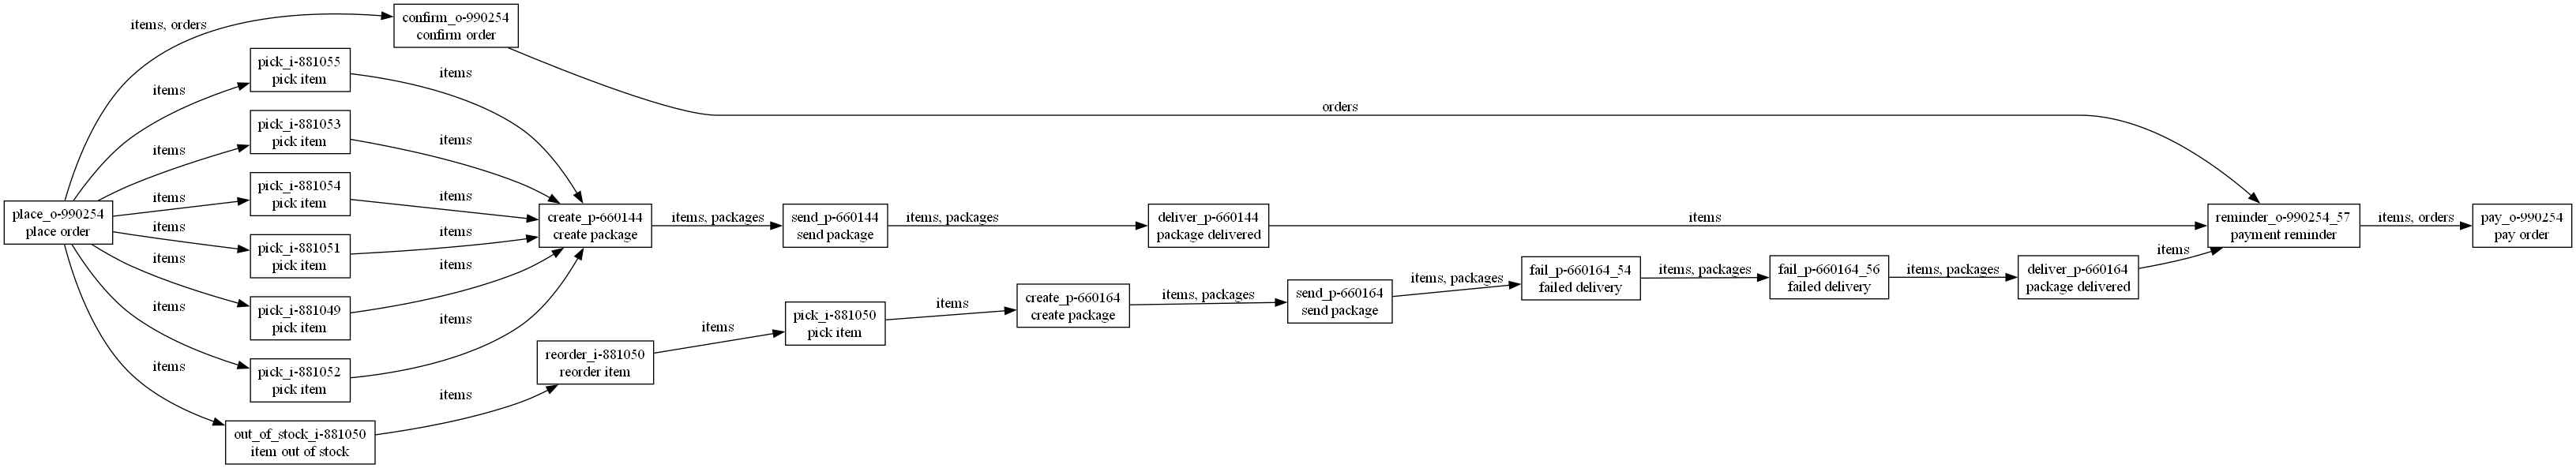

Instance Graph o-990042:


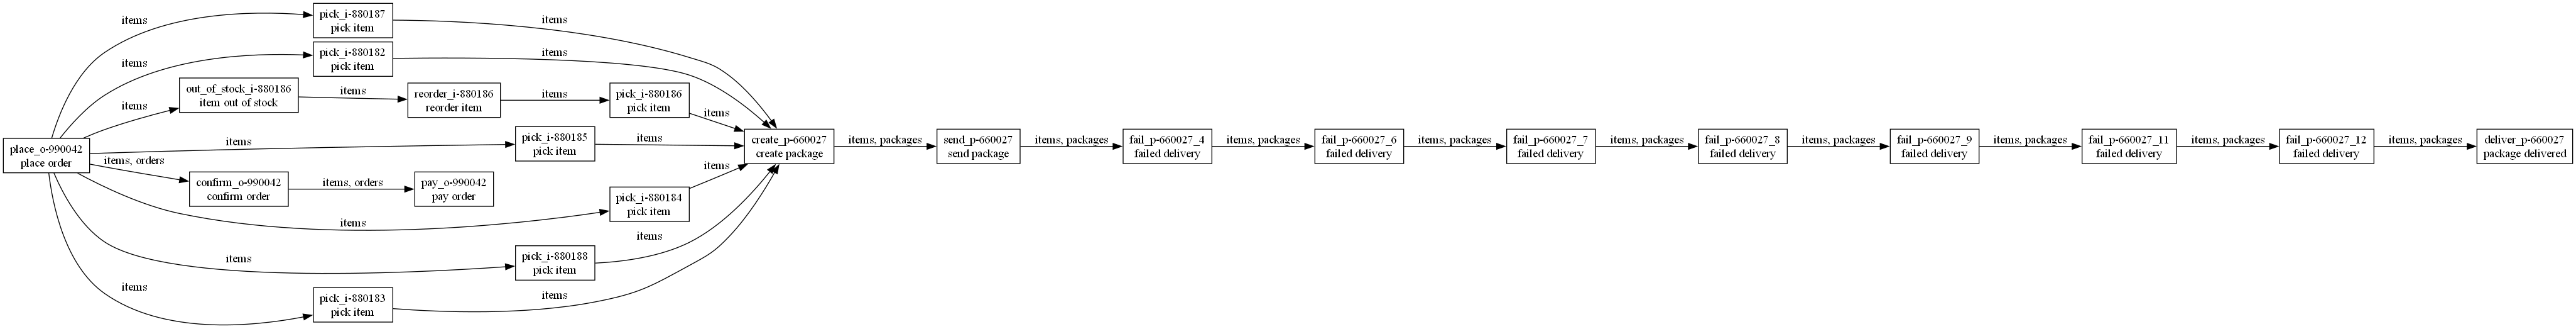

In [10]:
output_path_990254 = save_instance_graph(
    graphs["o-990254"],
    GRAPHS_DIR
    / (
        "order_management_"
        "o-990254_execution_screening.png"
    ),
)

print("Instance Graph o-990254:")

display(
    Image(
        filename=str(
            output_path_990254
        )
    )
)

output_path_990042 = save_instance_graph(
    graphs["o-990042"],
    GRAPHS_DIR
    / (
        "order_management_"
        "o-990042_execution_screening.png"
    ),
)

print("Instance Graph o-990042:")

display(
    Image(
        filename=str(
            output_path_990042
        )
    )
)

## 11. Conclusioni

Lo screening ha prodotto i seguenti risultati:

22 execution analizzate su 22;
22 grafi DAG;
22 grafi debolmente connessi;
copertura completa degli eventi;
nessun nodo isolato;
tutti i grafi transitivamente ridotti;
nessuna ripetizione sospetta sullo stesso oggetto;
gestione corretta dei loop failed delivery;
conservazione dell'incomparabilità per attività uguali riferite a oggetti differenti.

L'estensione corregge quindi un limite concreto della prima versione: le ripetizioni sullo stesso oggetto non vengono più interpretate automaticamente come parallelismo.

Resta però necessario distinguere questo risultato dalla conformità formale. Le relazioni sono ancora inferite dall'OC-DFG e non dalla semantica di esecuzione della OCPN. Il conformance checking object-centric costituisce un passaggio successivo.